# 00 — Data Audit: Raw Signal Quality Across Sessions

Purpose-built for cross-session, cross-participant investigation of `raw_events.parquet` —
distinct from `01_raw_behavioural_explorer.ipynb`, which is a single-session, app-agnostic
explorer. This notebook exists to answer specific open questions before `build_windows_dataset.py`
is designed, not to explore generically:

1. Do throttled event kinds (`pointermove`, `touchmove`, `scroll`, `devicemotion`,
   `deviceorientation`) show comb/quantization artifacts in inter-event timing?
2. How often does `deviceorientation.alpha` actually wrap 0°↔360° in real sessions?
3. Is `touchstart.force` quantization consistent across sessions/devices, or device-specific?
4. Are there real dropout gaps in `devicemotion`/`deviceorientation`, and how large/frequent?
5. Do the new P2 modalities (motion, orientation, scroll, drag/swipe) show any visible
   between-participant separation at all, even with only 2 participants / 3 sessions?

No behavioural features are computed here — this is signal quality and separability
investigation only, feeding design decisions for `build_windows_dataset.py`.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (14, 4)

RAW_EVENTS_PARQUET = "../../data/processed/raw_events.parquet"
df = pd.read_parquet(RAW_EVENTS_PARQUET)
print(f"{len(df):,} rows, {df.shape[1]} columns")
print(f"Sessions: {df['sessionId'].nunique()}, Participants: {df['participantId'].nunique()}")

44,155 rows, 167 columns
Sessions: 4, Participants: 3


## 1. Dataset overview

Orient on what's actually here before checking anything specific.

In [20]:
session_summary = (
    df.groupby(['sessionId', 'participantId', 'sessionIndex', 'deviceFamily', 'devicePlatform', 'deviceModel'])
    .agg(eventCount=('eventIndex', 'count'), maxTRelMs=('tRelMs', 'max'))
    .reset_index()
    .sort_values(['participantId', 'sessionIndex'])
)
session_summary

,sessionId,participantId,sessionIndex,deviceFamily,devicePlatform,deviceModel,eventCount,maxTRelMs
0,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,1,mobile,iphone,iphone_16,18920,376487
2,407ab28165b243dfaa35b57079af7ecd,pA6XL23,2,mobile,iphone,iphone_16,13438,259676
1,3e9ec1bb46ba4d8a8c4849d759e8d621,pCURDWC,1,desktop,laptop_desktop,macbook_trackpad,4670,186814
3,b1700a0f31cb4f16ba0a035b7ece41a2,pG5G4MS,5,mobile,iphone,iphone_16_plus,7127,143617


In [21]:
kind_counts = df['kind'].value_counts()
print(f"{len(kind_counts)} distinct event kinds")
kind_counts

45 distinct event kinds


kind
devicemotion                11123
deviceorientation           11042
touchmove                    6380
scroll                       4406
pointermove                  2640
pointerrawupdate             1194
carousel_scroll              1194
window_scroll                 831
pointerdown                   584
touchend                      523
touchstart                    523
keyup                         519
keydown                       519
beforeinput                   512
input                         512
pointercancel                 316
pointerup                     268
visual_viewport_resize        262
visual_viewport_scroll        133
task_end                      104
screen_view                   104
task_start                    104
resize                         99
blur                           35
focus                          35
gesture_drag_end               21
gesture_drag_start             21
passcode_digit_tap             16
account_card_selected          16
approval_

In [22]:
# Sparsity of payload_* columns — confirms per-kind flattening produced sensible sparse structure
payload_cols = [c for c in df.columns if c.startswith('payload_')]
sparsity = df[payload_cols].notna().mean().sort_values(ascending=False)
print(f"{len(payload_cols)} payload_* columns")
sparsity.head(20).to_frame('non_null_pct')

143 payload_* columns


,non_null_pct
payload_componentId,0.419703
payload_y,0.281939
payload_x,0.281939
payload_yNorm,0.281463
payload_xNorm,0.281463
payload_interval,0.251908
payload_rotAlpha,0.251885
payload_rotGamma,0.251885
payload_az,0.251885
payload_ay,0.251885


## 2. Throttled-kind interval check

`schema.js` throttles `pointermove`/`touchmove` to 16ms, `scroll` to 30ms,
`devicemotion`/`deviceorientation` to 50ms. If these throttle rates create a comb pattern
in inter-event timing (like the P1 `key_down_press_to_press_ms` mobile comb), that confirms
raw inter-event-interval isn't a usable behavioural timing feature for these kinds without
correction — the interval mostly measures the throttle setting, not the person.

**What to look for**: spikes at multiples of the throttle value (16/32/48ms etc.) rather than
a smooth spread. A smooth spread would mean the throttle isn't the dominant factor.

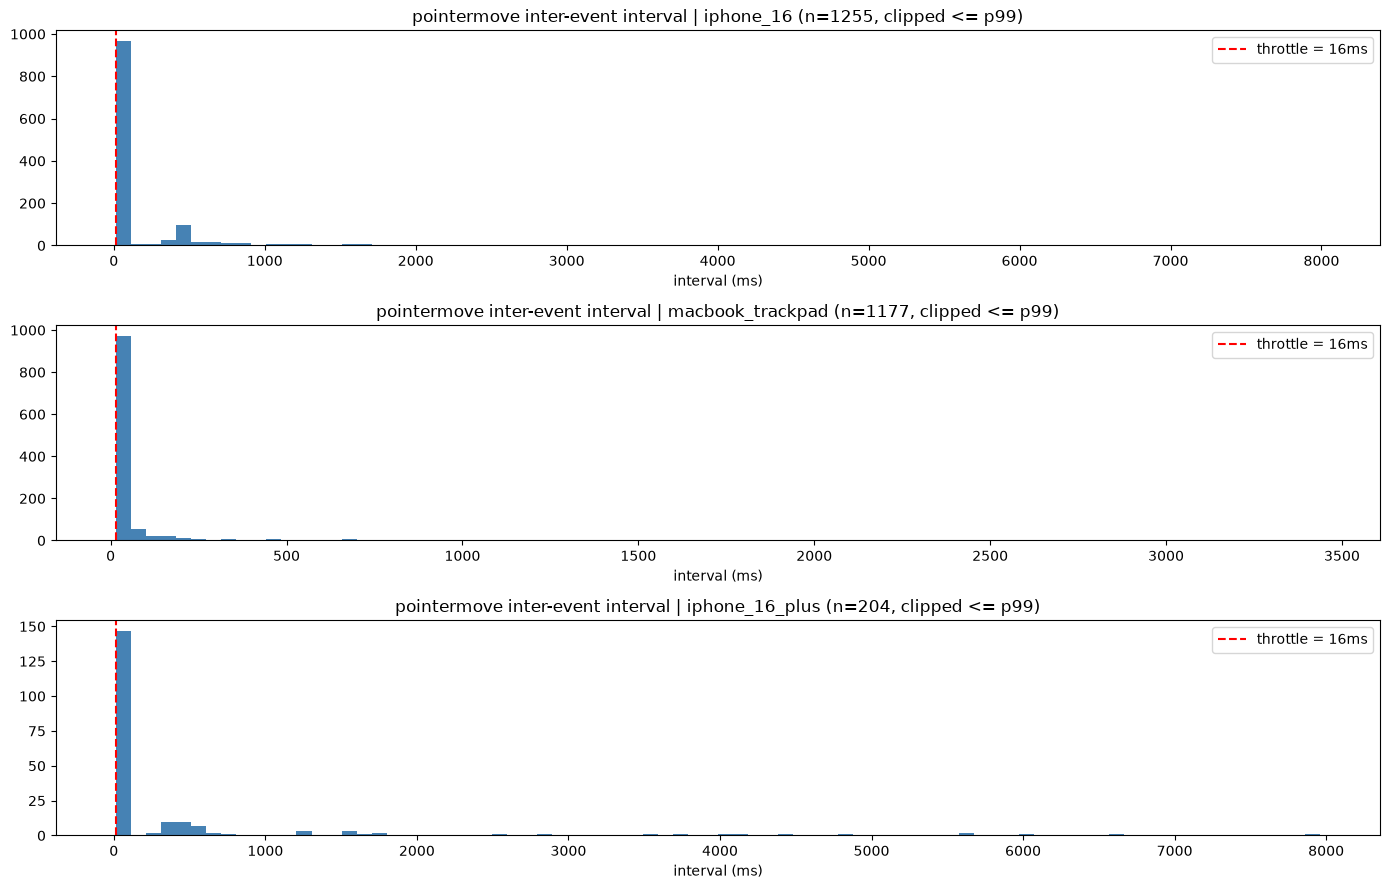

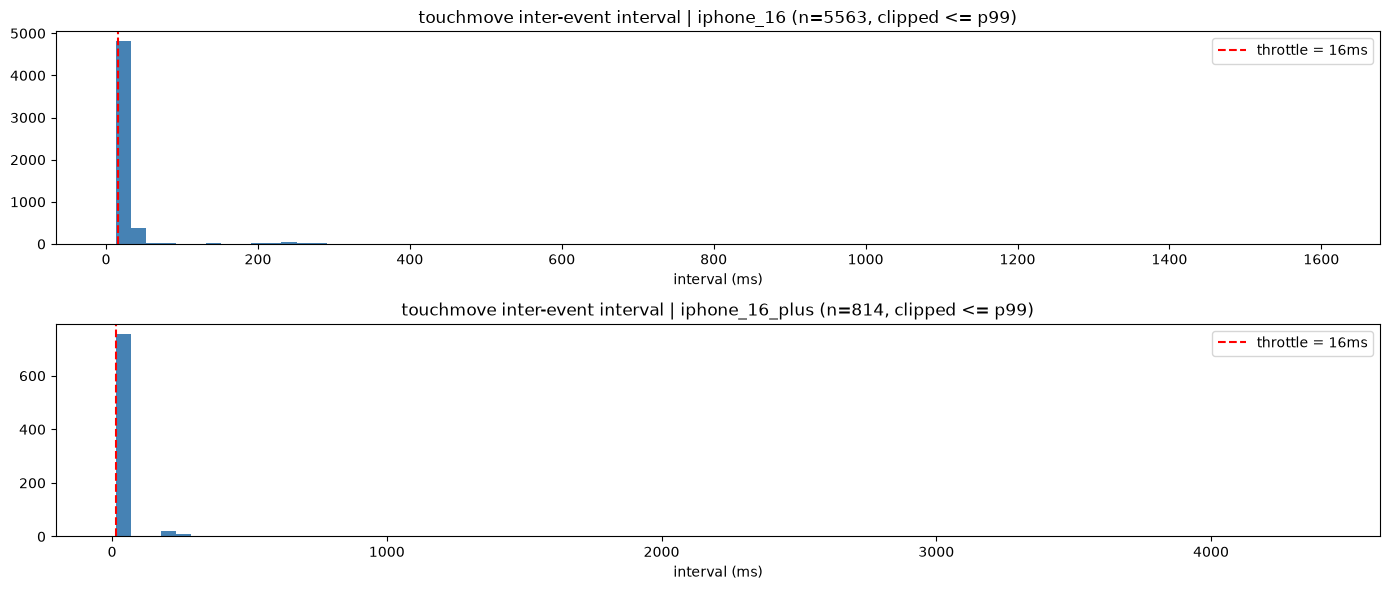

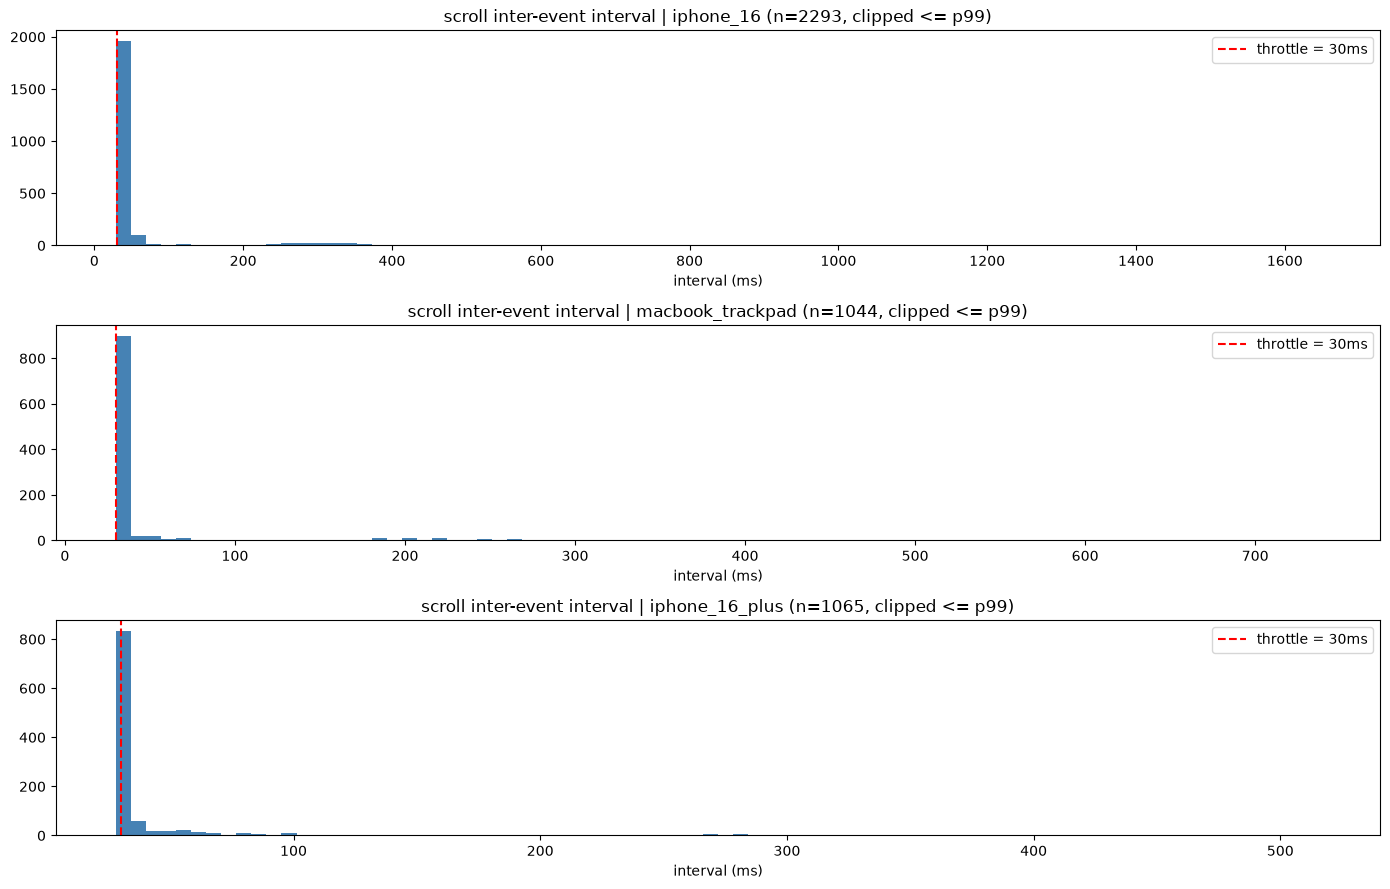

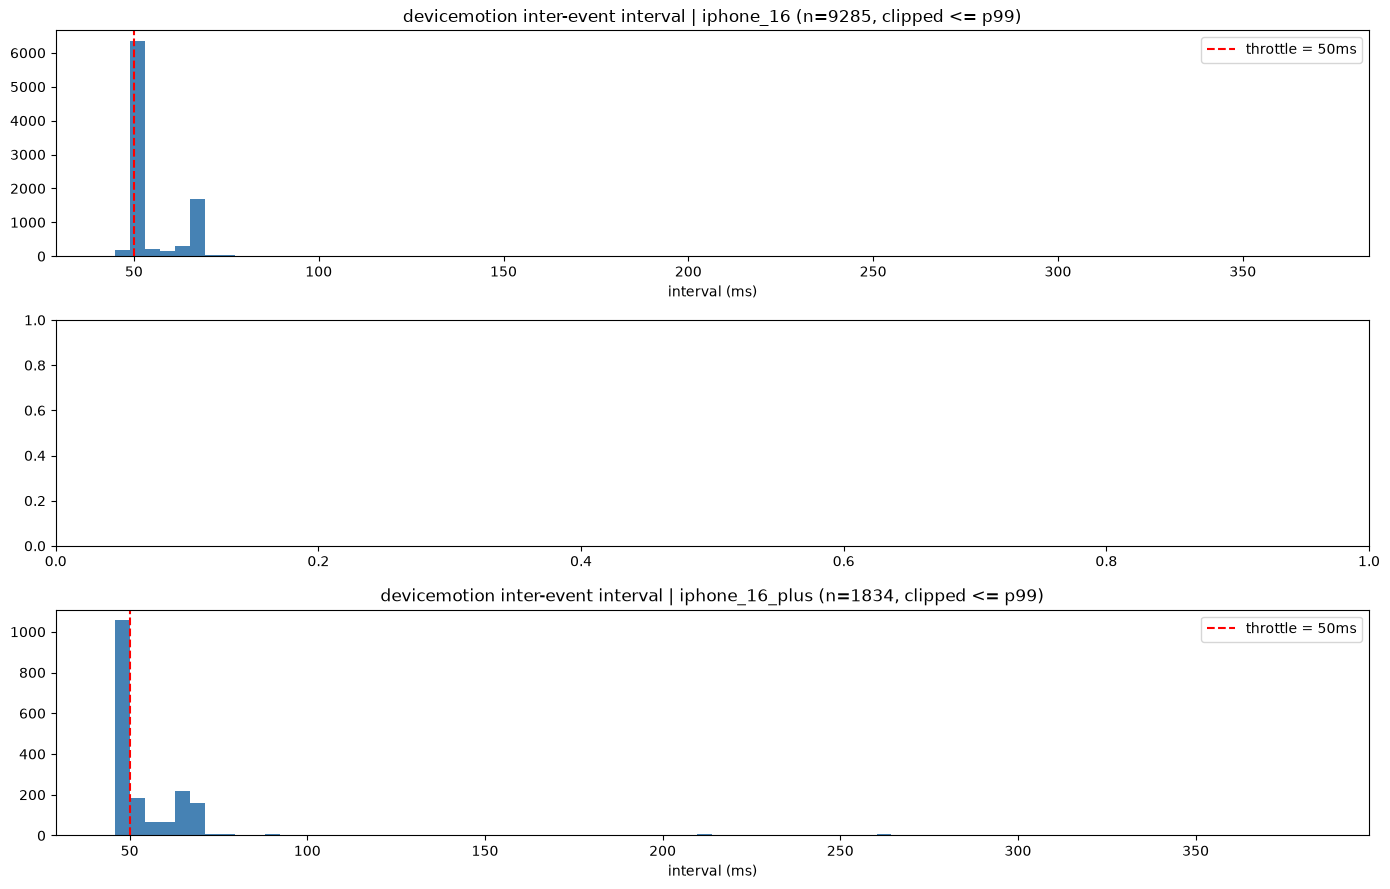

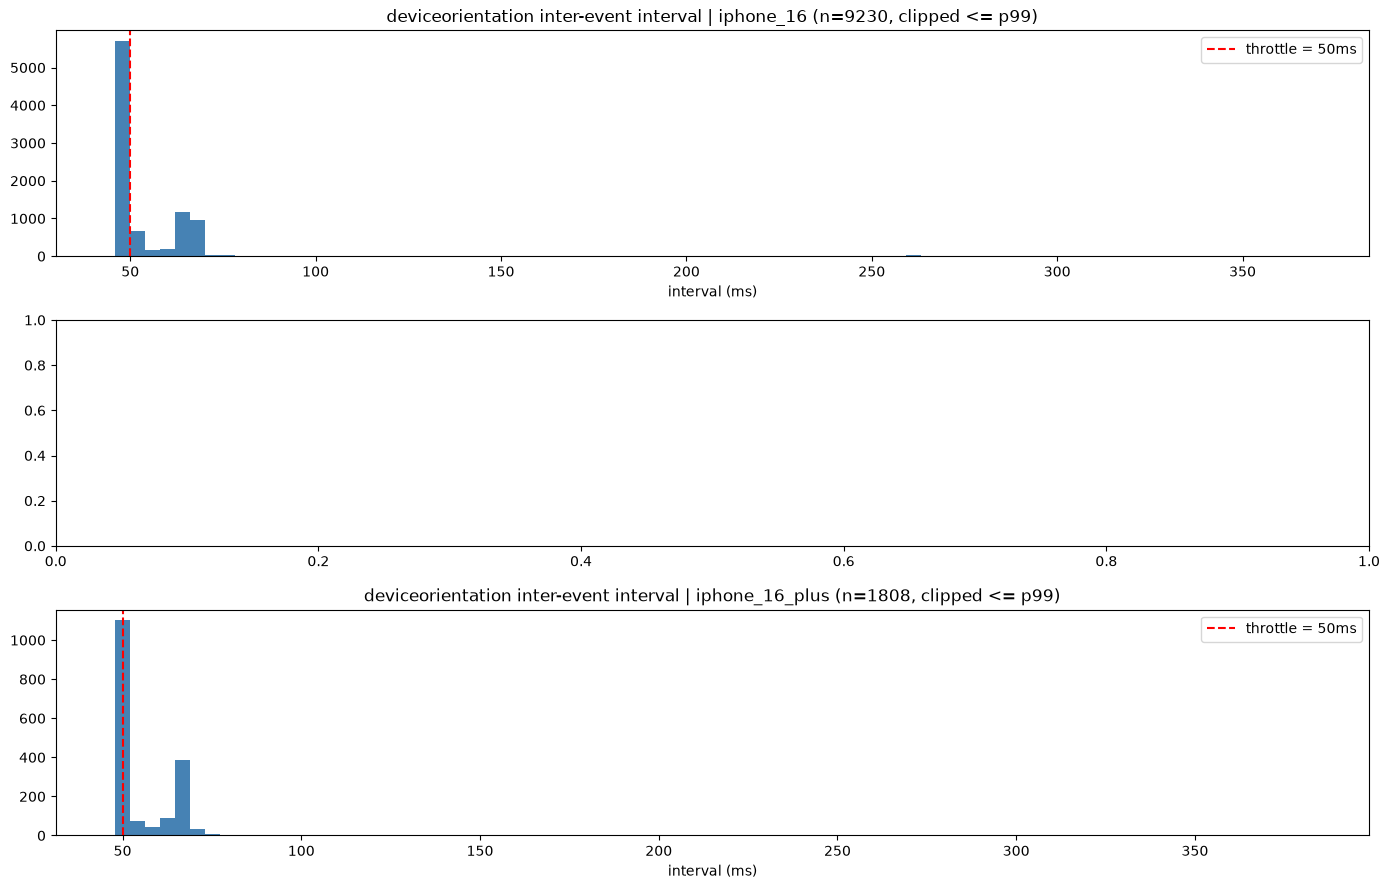

In [23]:
THROTTLED_KINDS = {
    'pointermove': 16,
    'touchmove': 16,
    'scroll': 30,
    'devicemotion': 50,
    'deviceorientation': 50,
}

def interval_hist_by_device_model(kind, throttle_ms, clip_pct=99):
    sub = df[df['kind'] == kind].sort_values(['sessionId', 'eventIndex'])
    if sub.empty:
        print(f"No '{kind}' events found.")
        return
    models = sub['deviceModel'].dropna().unique()
    fig, axes = plt.subplots(len(models), 1, figsize=(14, 3 * max(len(models), 1)), squeeze=False)
    for i, model in enumerate(models):
        model_sub = sub[sub['deviceModel'] == model]
        gaps = model_sub.groupby('sessionId')['tRelMs'].diff().dropna()
        if gaps.empty:
            continue
        clip_val = np.percentile(gaps, clip_pct)
        gaps_clipped = gaps[gaps <= clip_val]
        ax = axes[i][0]
        ax.hist(gaps_clipped, bins=80, color='steelblue')
        ax.axvline(throttle_ms, color='red', linestyle='--', label=f'throttle = {throttle_ms}ms')
        ax.set_title(f"{kind} inter-event interval | {model} (n={len(gaps)}, clipped <= p{clip_pct})")
        ax.set_xlabel('interval (ms)')
        ax.legend()
    plt.tight_layout()
    plt.show()

for kind, throttle in THROTTLED_KINDS.items():
    interval_hist_by_device_model(kind, throttle)

**Read this as**: if you see a comb (repeated spikes at multiples of the throttle value)
rather than a smooth decaying spread, raw inter-event-interval for that kind should NOT be
used as a naive timing feature. Position/value-based features (x/y trajectory shape, magnitude)
from the same events remain unaffected either way — only interval-based timing features are
at risk here.

## 3. `deviceorientation.alpha` wraparound check

`alpha` (compass heading) wraps 0°→360°. A window whose samples straddle the wrap point will
compute a garbage mean under naive averaging. Check how often this actually happens in real
sessions before deciding how much effort the sin/cos-encoding fix is worth.

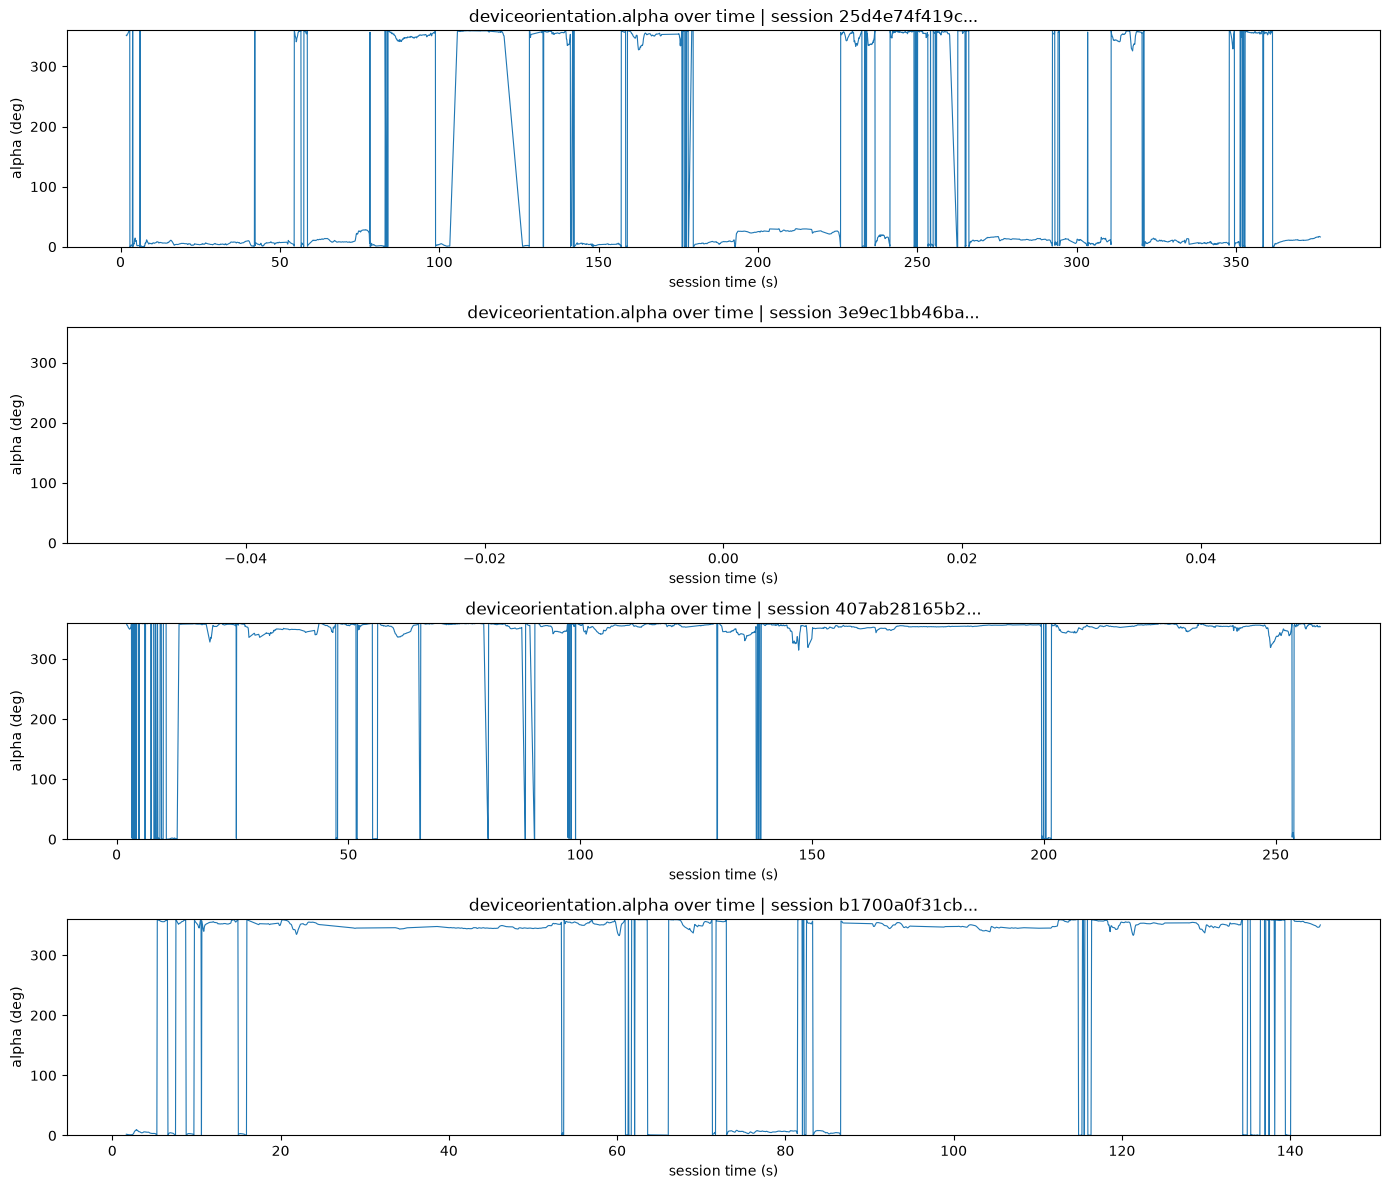

Likely wrap events per session (diff > 180 deg between consecutive samples):
sessionId
25d4e74f419c4f43a08fb5e0f46847a8    91
3e9ec1bb46ba4d8a8c4849d759e8d621     0
407ab28165b243dfaa35b57079af7ecd    66
b1700a0f31cb4f16ba0a035b7ece41a2    47
Name: payload_alpha, dtype: int64


In [24]:
orient = df[df['kind'] == 'deviceorientation'].sort_values(['sessionId', 'eventIndex'])
if orient.empty or 'payload_alpha' not in orient.columns:
    print("No deviceorientation.alpha data found.")
else:
    fig, axes = plt.subplots(orient['sessionId'].nunique(), 1, figsize=(14, 3 * orient['sessionId'].nunique()), squeeze=False)
    for i, (sid, sub) in enumerate(orient.groupby('sessionId')):
        ax = axes[i][0]
        ax.plot(sub['tRelMs'] / 1000, sub['payload_alpha'], linewidth=0.8)
        ax.set_title(f"deviceorientation.alpha over time | session {sid[:12]}...")
        ax.set_xlabel('session time (s)')
        ax.set_ylabel('alpha (deg)')
        ax.set_ylim(0, 360)
    plt.tight_layout()
    plt.show()

    # Count how many consecutive-sample deltas look like a wrap (large jump near the boundary)
    def count_likely_wraps(alpha_series):
        diffs = alpha_series.diff().abs()
        # A genuine wrap produces a diff near 360 (e.g. 359 -> 1 gives diff ~358)
        return int((diffs > 180).sum())

    wrap_counts = orient.groupby('sessionId')['payload_alpha'].apply(count_likely_wraps)
    print("Likely wrap events per session (diff > 180 deg between consecutive samples):")
    print(wrap_counts)

## 4. `touchstart.force` quantization check

Already confirmed 4 discrete values in one session. Check whether the same 4 values recur
across all sessions (pure hardware/OS quantization, not useful as a behavioural feature at
all) or differ by device (still not real force, but potentially a device fingerprint rather
than a person one).

In [25]:
touch_start = df[df['kind'] == 'touchstart']
if touch_start.empty or 'payload_force' not in touch_start.columns:
    print("No touchstart.force data found.")
else:
    force_by_session = (
        touch_start.groupby(['sessionId', 'deviceModel'])['payload_force']
        .apply(lambda s: sorted(s.dropna().unique()))
        .reset_index()
        .rename(columns={'payload_force': 'unique_force_values'})
    )
    force_by_session

**Read this as**: identical value sets across sessions/devices → drop this as a behavioural
feature entirely, it's a hardware constant. Different value sets by device → still not usable
as "how hard this person presses," but worth flagging as a potential device-identity leak if
kept in any form.

## 5. Motion/orientation dropout gaps

Known iOS quirk: `devicemotion`/`deviceorientation` can silently stop updating for a second
or more, then resume, independent of anything the person did. A window overlapping one of
these gaps would compute motion statistics from almost no real data.

In [26]:
def dropout_gap_report(kind, throttle_ms, gap_multiple_threshold=5):
    sub = df[df['kind'] == kind].sort_values(['sessionId', 'eventIndex'])
    if sub.empty:
        print(f"No '{kind}' events found.")
        return
    threshold_ms = throttle_ms * gap_multiple_threshold
    rows = []
    for sid, s in sub.groupby('sessionId'):
        gaps = s['tRelMs'].diff().dropna()
        big_gaps = gaps[gaps > threshold_ms]
        rows.append({
            'sessionId': sid,
            'n_events': len(s),
            'n_gaps_over_threshold': len(big_gaps),
            'threshold_ms': threshold_ms,
            'max_gap_ms': float(gaps.max()) if len(gaps) else None,
            'total_dropout_ms': float(big_gaps.sum()) if len(big_gaps) else 0.0,
        })
    return pd.DataFrame(rows)

print("devicemotion dropout report (gaps > 5x the 50ms throttle):")
display(dropout_gap_report('devicemotion', 50))

print()
print("deviceorientation dropout report:")
display(dropout_gap_report('deviceorientation', 50))

devicemotion dropout report (gaps > 5x the 50ms throttle):


,sessionId,n_events,n_gaps_over_threshold,threshold_ms,max_gap_ms,total_dropout_ms
0,25d4e74f419c4f43a08fb5e0f46847a8,5432,103,250,5861.0,81174.0
1,3e9ec1bb46ba4d8a8c4849d759e8d621,1,0,250,NaN,0.0
2,407ab28165b243dfaa35b57079af7ecd,3855,77,250,2942.0,42998.0
3,b1700a0f31cb4f16ba0a035b7ece41a2,1835,40,250,4626.0,41522.0



deviceorientation dropout report:


,sessionId,n_events,n_gaps_over_threshold,threshold_ms,max_gap_ms,total_dropout_ms
0,25d4e74f419c4f43a08fb5e0f46847a8,5406,104,250,5827.0,81246.0
1,3e9ec1bb46ba4d8a8c4849d759e8d621,1,0,250,NaN,0.0
2,407ab28165b243dfaa35b57079af7ecd,3826,79,250,2942.0,43560.0
3,b1700a0f31cb4f16ba0a035b7ece41a2,1809,39,250,4626.0,41287.0


**Read this as**: if `n_gaps_over_threshold` and `total_dropout_ms` are near zero, dropout
isn't currently a practical concern — revisit once more sessions exist. If gaps are frequent
or long relative to the 7.5s window size under discussion, windows overlapping a gap should be
flagged (e.g. a `motionCoveragePct` column) rather than trusted at face value.

## 6. Cross-participant separability — new P2 modalities

Same style as the P1 slides showing `key_up_dwell_ms` trajectories per participant. With only
2 participants / 3 sessions this can't prove anything statistically — it's a first look at
whether these new modalities show ANY visible between-person separation worth pursuing further
as the cohort grows, or whether they look tangled/indistinguishable from the start.

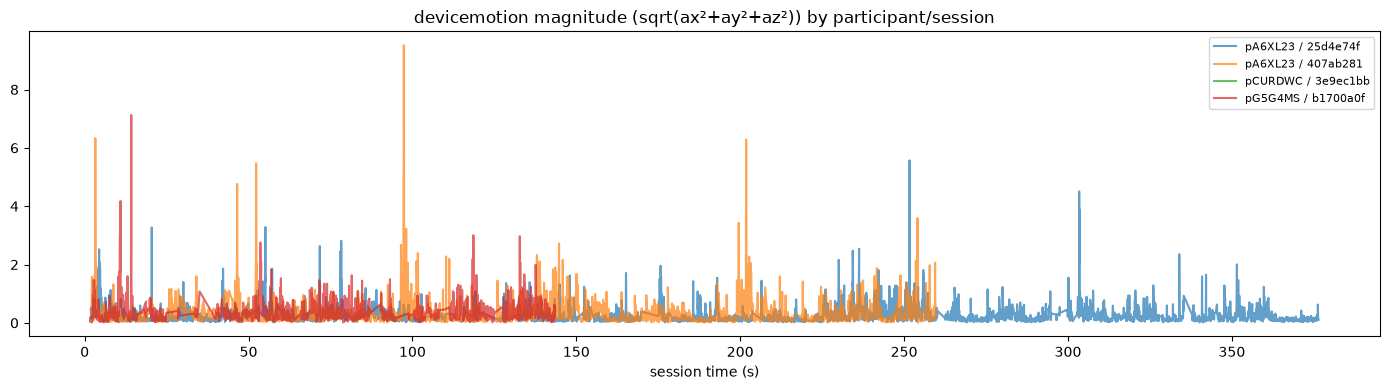

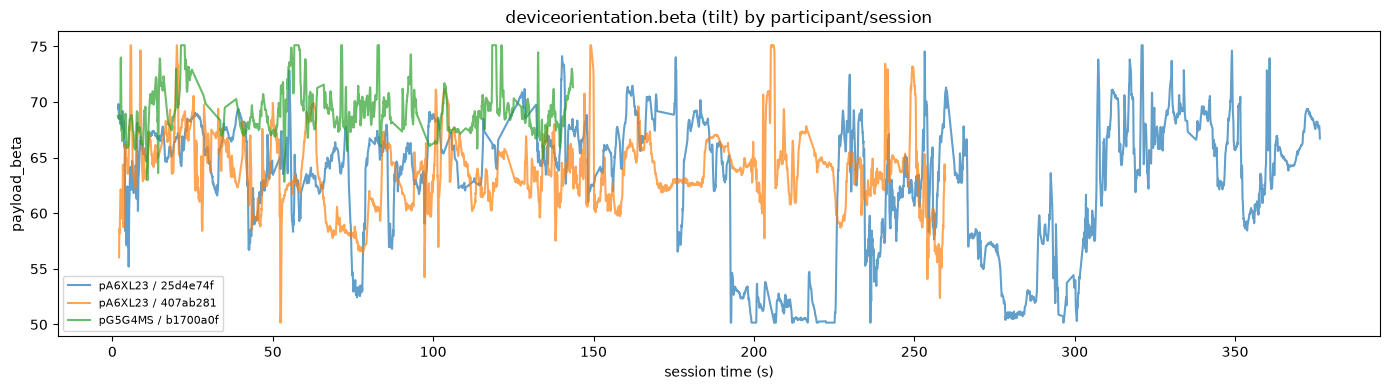

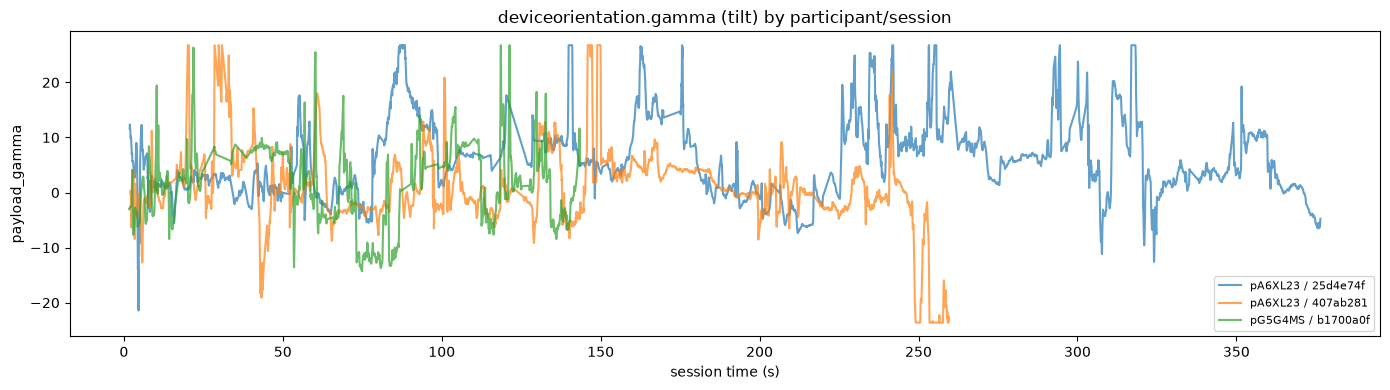

In [27]:
def participant_trajectory_plot(kind, payload_col, title=None, clip_pct=(1, 99)):
    sub = df[(df['kind'] == kind) & df[payload_col].notna()].copy() if payload_col in df.columns else pd.DataFrame()
    if sub.empty:
        print(f"No usable '{kind}' / '{payload_col}' data found.")
        return
    lo, hi = np.percentile(sub[payload_col], clip_pct)
    fig, ax = plt.subplots(figsize=(14, 4))
    for pid, p_sub in sub.groupby('participantId'):
        for sid, s_sub in p_sub.groupby('sessionId'):
            s_sub = s_sub.sort_values('tRelMs')
            y = s_sub[payload_col].clip(lo, hi)
            ax.plot(s_sub['tRelMs'] / 1000, y, alpha=0.7, label=f"{pid} / {sid[:8]}")
    ax.set_title(title or f"{kind}.{payload_col} by participant/session")
    ax.set_xlabel('session time (s)')
    ax.set_ylabel(payload_col)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# Motion magnitude proxy (linear acceleration components)
if all(c in df.columns for c in ['payload_ax', 'payload_ay', 'payload_az']):
    motion = df[df['kind'] == 'devicemotion'].copy()
    motion['motion_magnitude'] = np.sqrt(motion['payload_ax']**2 + motion['payload_ay']**2 + motion['payload_az']**2)
    fig, ax = plt.subplots(figsize=(14, 4))
    for pid, p_sub in motion.groupby('participantId'):
        for sid, s_sub in p_sub.groupby('sessionId'):
            s_sub = s_sub.sort_values('tRelMs')
            ax.plot(s_sub['tRelMs'] / 1000, s_sub['motion_magnitude'], alpha=0.7, label=f"{pid} / {sid[:8]}")
    ax.set_title("devicemotion magnitude (sqrt(ax²+ay²+az²)) by participant/session")
    ax.set_xlabel('session time (s)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

participant_trajectory_plot('deviceorientation', 'payload_beta', title='deviceorientation.beta (tilt) by participant/session')
participant_trajectory_plot('deviceorientation', 'payload_gamma', title='deviceorientation.gamma (tilt) by participant/session')

In [28]:
# Drag/swipe kinematics — sparse (2 per session), so this is descriptive only, not a trend
for kind in ['gesture_drag_end', 'card_swipe_summary', 'approval_swipe_release']:
    sub = df[df['kind'] == kind]
    if sub.empty:
        print(f"No '{kind}' events found.")
        continue
    candidate_cols = [c for c in sub.columns if c.startswith('payload_') and sub[c].notna().any()]
    print(f"--- {kind} ({len(sub)} events) ---")
    display(sub[['sessionId', 'participantId'] + candidate_cols].dropna(axis=1, how='all'))

--- gesture_drag_end (21 events) ---


,sessionId,participantId,payload_componentId,payload_distancePx,payload_durationMs,payload_pointerType,payload_samples
8542,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,pot_drag_thumb,1050.610,6767.0,touch,269.0
11322,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,approval_swipe_thumb,322.540,526.0,touch,31.0
11395,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,approval_swipe_thumb,77.268,226.0,touch,11.0
11500,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,approval_swipe_thumb,655.090,591.0,touch,35.0
11545,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,approval_swipe_thumb,109.116,128.0,touch,8.0
11582,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,approval_swipe_thumb,73.783,128.0,touch,6.0
15905,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,pot_drag_thumb,231.054,1843.0,touch,101.0
17746,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,approval_swipe_thumb,367.483,794.0,touch,45.0
20154,3e9ec1bb46ba4d8a8c4849d759e8d621,pCURDWC,pot_drag_thumb,300.366,1145.9,mouse,43.0
21000,3e9ec1bb46ba4d8a8c4849d759e8d621,pCURDWC,approval_swipe_thumb,446.948,622.9,mouse,30.0


--- card_swipe_summary (8 events) ---


,sessionId,participantId,payload_activeTaskId,payload_componentId,payload_contentSetIndex,payload_maxScrollLeft,payload_maxScrollLeftRatio,payload_selectedCard,payload_swiped,payload_targetCardId,payload_targetCardSelected
10416,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,insights_swipe_cards_01,spending_card_carousel,0.0,1110.0,0.570,travel,True,travel,True
17139,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,insights_swipe_cards_02,spending_card_carousel,1.0,1138.0,0.584,entertainment,True,entertainment,True
20799,3e9ec1bb46ba4d8a8c4849d759e8d621,pCURDWC,insights_swipe_cards_01,spending_card_carousel,0.0,2122.0,0.883,entertainment,True,entertainment,True
23060,3e9ec1bb46ba4d8a8c4849d759e8d621,pCURDWC,insights_swipe_cards_02,spending_card_carousel,1.0,2348.0,0.977,subscriptions,True,subscriptions,True
29891,407ab28165b243dfaa35b57079af7ecd,pA6XL23,insights_swipe_cards_01,spending_card_carousel,0.0,1391.0,0.714,groceries,True,groceries,True
35121,407ab28165b243dfaa35b57079af7ecd,pA6XL23,insights_swipe_cards_02,spending_card_carousel,1.0,1110.0,0.570,fitness,True,fitness,True
40227,b1700a0f31cb4f16ba0a035b7ece41a2,pG5G4MS,insights_swipe_cards_01,spending_card_carousel,0.0,1222.0,0.571,food,True,food,True
43295,b1700a0f31cb4f16ba0a035b7ece41a2,pG5G4MS,insights_swipe_cards_02,spending_card_carousel,1.0,1538.0,0.718,groceries,True,groceries,True


--- approval_swipe_release (12 events) ---


,sessionId,participantId,payload_activeTaskId,payload_approved,payload_componentId,payload_durationMs,payload_swipeRatio
11321,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,secure_approval_01,True,approval_swipe_thumb,526.0,1.0
11394,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,secure_approval_01,True,approval_swipe_thumb,226.0,1.0
11499,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,secure_approval_01,True,approval_swipe_thumb,591.0,1.0
11544,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,secure_approval_01,True,approval_swipe_thumb,128.0,1.0
11581,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,secure_approval_01,True,approval_swipe_thumb,128.0,1.0
17745,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,secure_approval_02,True,approval_swipe_thumb,794.0,1.0
20999,3e9ec1bb46ba4d8a8c4849d759e8d621,pCURDWC,secure_approval_01,True,approval_swipe_thumb,622.9,1.0
23267,3e9ec1bb46ba4d8a8c4849d759e8d621,pCURDWC,secure_approval_02,True,approval_swipe_thumb,555.4,1.0
30395,407ab28165b243dfaa35b57079af7ecd,pA6XL23,secure_approval_01,True,approval_swipe_thumb,892.0,1.0
35765,407ab28165b243dfaa35b57079af7ecd,pA6XL23,secure_approval_02,True,approval_swipe_thumb,460.0,1.0


**Read this as**: look for participants whose lines sit visibly apart from each other
(different baseline level, different variability) versus lines that are fully tangled together.
Visible separation here is encouraging but not proof — with 2 participants it's equally
consistent with "real behavioural difference" and "these two happen to use different phone
models" (check `deviceModel` in the session summary table above before reading too much into
any separation you see).

## Summary / next steps

Fill in after running against real data:

- **Throttle comb pattern (§2)**: present? which kinds?
- **Alpha wraps (§3)**: how often, worth the sin/cos fix now or later?
- **Force quantization (§4)**: same values everywhere, or device-specific?
- **Dropout gaps (§5)**: material or negligible at current sample size?
- **New-modality separability (§6)**: any visible signal, or dominated by device/noise?

These findings feed directly into `build_windows_dataset.py`'s feature list and the
confidence-weighted fusion design discussed separately.

## 7. Refined alpha wrap check + sin/cos transform

The naive wrap check in §3 (diff > 180°) can't distinguish a genuine 0°/360° crossing from
a large real orientation change coinciding with a dropout gap. This refines it: a wrap only
counts if (a) consecutive samples sit near opposite ends of the range (one <20°, one >340°)
AND (b) they aren't separated by a large time gap. Also demonstrates the sin/cos fix directly
on a real straddling window.

In [29]:
def refined_wrap_count(session_df, gap_threshold_ms=250):
    alpha = session_df['payload_alpha'].astype(float)
    tRel = session_df['tRelMs'].astype(float)
    time_gap = tRel.diff()
    near_zero = alpha < 20
    near_360 = alpha > 340
    prev_near_zero = near_zero.shift(1)
    prev_near_360 = near_360.shift(1)
    naive = (alpha.diff().abs() > 180)
    true_wrap = ((near_zero & prev_near_360) | (near_360 & prev_near_zero)) & (time_gap <= gap_threshold_ms)
    return {
        'naive_wrap_count': int(naive.sum()),
        'refined_wrap_count': int(true_wrap.sum()),
        'excluded_due_to_gap_coincidence': int((naive & (time_gap > gap_threshold_ms)).sum()),
    }

orient_all = df[df['kind'] == 'deviceorientation'].sort_values(['sessionId', 'eventIndex'])
refined_results = []
for sid, s in orient_all.groupby('sessionId'):
    r = refined_wrap_count(s)
    r['sessionId'] = sid
    refined_results.append(r)
pd.DataFrame(refined_results)[['sessionId', 'naive_wrap_count', 'refined_wrap_count', 'excluded_due_to_gap_coincidence']]

,sessionId,naive_wrap_count,refined_wrap_count,excluded_due_to_gap_coincidence
0,25d4e74f419c4f43a08fb5e0f46847a8,91,86,5
1,3e9ec1bb46ba4d8a8c4849d759e8d621,0,0,0
2,407ab28165b243dfaa35b57079af7ecd,66,61,5
3,b1700a0f31cb4f16ba0a035b7ece41a2,47,47,0


In [30]:
# Demonstrate the sin/cos fix on a real straddling window from one session
def demo_sin_cos_fix(session_df, n=1):
    alpha = session_df['payload_alpha'].astype(float).reset_index(drop=True)
    wrap_positions = alpha.index[(alpha < 10) & (alpha.shift(1) > 350)]
    if len(wrap_positions) == 0:
        print("No clean wrap example found in this session.")
        return
    pos = wrap_positions[0]
    window = session_df.reset_index(drop=True).iloc[max(0, pos - 3):pos + 3]
    print(window[['tRelMs', 'payload_alpha']])
    raw_mean = window['payload_alpha'].astype(float).mean()
    s = np.sin(np.radians(window['payload_alpha'].astype(float)))
    c = np.cos(np.radians(window['payload_alpha'].astype(float)))
    circ_mean = (np.degrees(np.arctan2(s.mean(), c.mean())) + 360) % 360
    print(f"naive raw mean:      {raw_mean:.1f} deg  (wrong when straddling)")
    print(f"sin/cos circular mean: {circ_mean:.1f} deg  (correct)")

first_session = orient_all['sessionId'].iloc[0]
demo_sin_cos_fix(orient_all[orient_all['sessionId'] == first_session])

    tRelMs  payload_alpha
17    2771       358.7101
18    2841       358.9801
19    2904       359.4230
20    2954         0.1081
21    3004         0.7638
22    3071         0.9052
naive raw mean:      179.8 deg  (wrong when straddling)
sin/cos circular mean: 359.8 deg  (correct)


**Recommendation for `build_windows_dataset.py`**: store `payload_alpha_sin = sin(radians(alpha))`
and `payload_alpha_cos = cos(radians(alpha))` at the raw layer (or compute at window-aggregation
time), and aggregate those instead of raw `alpha`. Recover a representative angle from a window's
mean sin/cos via `atan2` if a human-readable degree value is ever needed for reporting.

## 8. Motion/orientation variance and tremor — better candidates than raw magnitude

Raw tilt/acceleration is dominated by *what task someone is doing* (holding still to read vs.
actively scrolling), which likely swamps anything personal. These are more standard in the
motion-biometrics literature: rolling variance of tilt (steadiness of grip, not absolute angle),
jerk (rate of change of acceleration — P1 already used this concept for pointer trajectories),
and dominant tremor frequency (physiological hand tremor sits in a fairly consistent band).

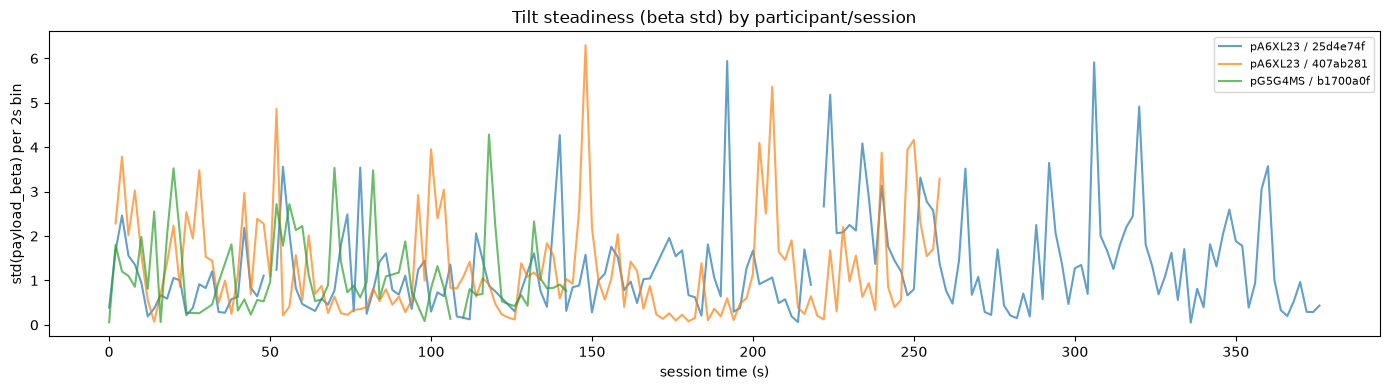

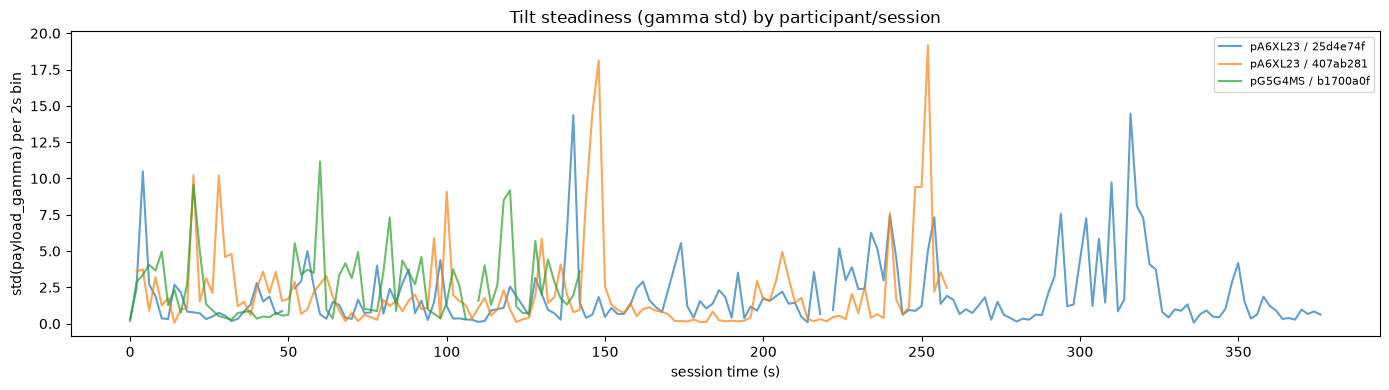

In [31]:
def rolling_variance_by_participant(kind, payload_col, bin_seconds=2, title=None):
    sub = df[(df['kind'] == kind) & df[payload_col].notna()].copy() if payload_col in df.columns else pd.DataFrame()
    if sub.empty:
        print(f"No usable '{kind}' / '{payload_col}' data found.")
        return
    fig, ax = plt.subplots(figsize=(14, 4))
    for pid, p_sub in sub.groupby('participantId'):
        for sid, s_sub in p_sub.groupby('sessionId'):
            s_sub = s_sub.sort_values('tRelMs').copy()
            s_sub['time_bin'] = (s_sub['tRelMs'] // (bin_seconds * 1000)).astype(int)
            binned_std = s_sub.groupby('time_bin')[payload_col].std()
            binned_t = binned_std.index * bin_seconds
            ax.plot(binned_t, binned_std.values, alpha=0.7, label=f"{pid} / {sid[:8]}")
    ax.set_title(title or f"{kind}.{payload_col} rolling std ({bin_seconds}s bins) by participant/session")
    ax.set_xlabel('session time (s)')
    ax.set_ylabel(f'std({payload_col}) per {bin_seconds}s bin')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

rolling_variance_by_participant('deviceorientation', 'payload_beta', title='Tilt steadiness (beta std) by participant/session')
rolling_variance_by_participant('deviceorientation', 'payload_gamma', title='Tilt steadiness (gamma std) by participant/session')

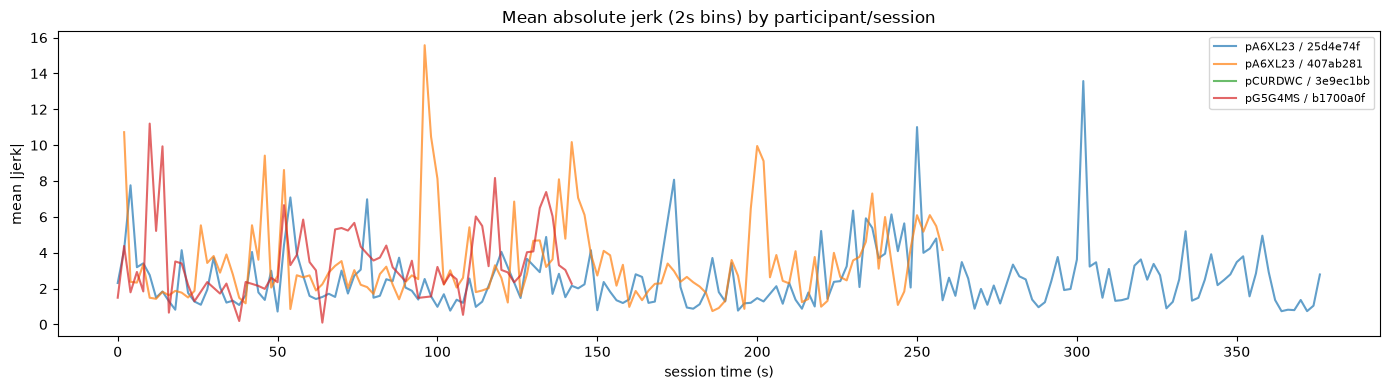

In [32]:
# Jerk: rate of change of motion magnitude, same concept as P1's mean_abs_jerk for pointer trajectories
motion = df[df['kind'] == 'devicemotion'].copy()
if all(c in motion.columns for c in ['payload_ax', 'payload_ay', 'payload_az']):
    motion['motion_magnitude'] = np.sqrt(motion['payload_ax']**2 + motion['payload_ay']**2 + motion['payload_az']**2)
    fig, ax = plt.subplots(figsize=(14, 4))
    for pid, p_sub in motion.groupby('participantId'):
        for sid, s_sub in p_sub.groupby('sessionId'):
            s_sub = s_sub.sort_values('tRelMs').copy()
            dt = s_sub['tRelMs'].diff() / 1000.0
            dmag = s_sub['motion_magnitude'].diff()
            jerk = (dmag / dt).abs()
            s_sub['time_bin'] = (s_sub['tRelMs'] // 2000).astype(int)
            binned_jerk = pd.Series(jerk.values, index=s_sub.index).groupby(s_sub['time_bin']).mean()
            ax.plot(binned_jerk.index * 2, binned_jerk.values, alpha=0.7, label=f"{pid} / {sid[:8]}")
    ax.set_title('Mean absolute jerk (2s bins) by participant/session')
    ax.set_xlabel('session time (s)')
    ax.set_ylabel('mean |jerk|')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Missing ax/ay/az columns.")

**Read this as**: look for participants whose variance/jerk level sits at a visibly different
baseline, even if raw magnitude (§6) looked tangled. Still only 2 participants — this is a
"does this look more promising than raw magnitude" check, not a conclusion.

## 9. Quantifying swipe/drag retry behaviour

Reuses P1's `slope_of_series`/trend-of-series pattern, applied per task-attempt-sequence instead
of per-window. For each `taskId` that has gesture events, compute: attempt count, time from first
attempt to the successful one, inter-attempt latency (hesitation between a failed attempt and the
next), and whether duration/quality trends across attempts.

In [33]:
def summarise_gesture_attempts(release_kind, success_field=None):
    sub = df[df['kind'] == release_kind].copy()
    if sub.empty:
        print(f"No '{release_kind}' events found.")
        return pd.DataFrame()

    rows = []
    group_cols = ['sessionId', 'participantId', 'payload_activeTaskId'] if 'payload_activeTaskId' in sub.columns else ['sessionId', 'participantId']
    for keys, g in sub.groupby(group_cols):
        g = g.sort_values('tRelMs')
        attempt_count = len(g)
        first_start = g['tRelMs'].iloc[0]
        last_end = g['tRelMs'].iloc[-1]
        time_to_last_attempt = last_end - first_start
        inter_attempt_gaps = g['tRelMs'].diff().dropna().tolist()
        duration_col = 'payload_durationMs' if 'payload_durationMs' in g.columns else None
        duration_trend = None
        if duration_col and attempt_count >= 2:
            vals = g[duration_col].astype(float).values
            duration_trend = float(np.polyfit(np.arange(len(vals)), vals, 1)[0])
        row = dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
        row.update({
            'attempt_count': attempt_count,
            'time_to_last_attempt_ms': float(time_to_last_attempt),
            'inter_attempt_gaps_ms': inter_attempt_gaps,
            'duration_trend_ms_per_attempt': duration_trend,
        })
        rows.append(row)
    return pd.DataFrame(rows).sort_values('attempt_count', ascending=False)

print("--- approval_swipe_release attempts per task ---")
display(summarise_gesture_attempts('approval_swipe_release'))

--- approval_swipe_release attempts per task ---


,sessionId,participantId,payload_activeTaskId,attempt_count,time_to_last_attempt_ms,inter_attempt_gaps_ms,duration_trend_ms_per_attempt
0,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,secure_approval_01,5,3360.0,"[1213.0, 982.0, 599.0, 566.0]",-89.4
1,25d4e74f419c4f43a08fb5e0f46847a8,pA6XL23,secure_approval_02,1,0.0,[],NaN
2,3e9ec1bb46ba4d8a8c4849d759e8d621,pCURDWC,secure_approval_01,1,0.0,[],NaN
3,3e9ec1bb46ba4d8a8c4849d759e8d621,pCURDWC,secure_approval_02,1,0.0,[],NaN
4,407ab28165b243dfaa35b57079af7ecd,pA6XL23,secure_approval_01,1,0.0,[],NaN
5,407ab28165b243dfaa35b57079af7ecd,pA6XL23,secure_approval_02,1,0.0,[],NaN
6,b1700a0f31cb4f16ba0a035b7ece41a2,pG5G4MS,secure_approval_01,1,0.0,[],NaN
7,b1700a0f31cb4f16ba0a035b7ece41a2,pG5G4MS,secure_approval_02,1,0.0,[],NaN


**Read this as**: `attempt_count > 1` rows are the interesting ones — someone needing multiple
tries at the same gesture. `duration_trend_ms_per_attempt` negative means attempts got faster
(learning/adapting within the task); positive means they got slower (fatigue/frustration).
`inter_attempt_gaps_ms` shows hesitation between a failed attempt and the next one. With only a
handful of multi-attempt cases so far this is descriptive, not yet a trained feature — but it's
cheap to compute per session going forward and worth tracking as the cohort grows.

## 10. Segmenting by concurrent activity — is "tangled" actually mixing regimes?

§8's variance/jerk comparison looked tangled across the whole session. That's plausibly because
it's mixing genuinely different physical regimes together — motion while actively dragging a
thumb is not comparable to motion while passively reading a screen, regardless of who's holding
the phone. Comparing whole-session variance conflates "what task is this" with "who is this,"
which is exactly the confound the multi-modal fusion design (context as a weight, not an
identity feature) was meant to avoid — this applies just as much to *analysis* as it does to
*modelling*.

Every raw event already carries its own `taskId` (99.7% populated on `devicemotion`, confirmed
directly against the real data), so this needs no new instrumentation — just a coarse mapping
from each task's base ID to what kind of physical activity it represents, taken directly from
`tasks.js`'s own task list.

In [34]:
BASE_TASK_TYPE = {
    'unlock_code': 'tap', 'home_balance_check': 'tap', 'home_explore_cards': 'scroll',
    'activity_search': 'type', 'activity_filter_review': 'tap', 'activity_scroll_select': 'scroll',
    'transaction_category': 'tap', 'transaction_note': 'type', 'pots_drag_amount': 'drag_swipe',
    'pots_transfer': 'tap', 'insights_swipe_cards': 'drag_swipe', 'insights_review': 'tap',
    'secure_approval': 'drag_swipe', 'secure_reply': 'type', 'finish_feeling': 'tap',
}

def base_task_id(task_id):
    if pd.isna(task_id):
        return None
    parts = str(task_id).rsplit('_', 1)
    return parts[0] if len(parts) == 2 and parts[1].isdigit() else task_id

def add_activity_type(sub):
    sub = sub.copy()
    sub['baseTaskId'] = sub['taskId'].apply(base_task_id)
    sub['activityType'] = sub['baseTaskId'].map(BASE_TASK_TYPE).fillna('pre_task_or_other')
    return sub

motion_tagged = add_activity_type(df[df['kind'] == 'devicemotion'])
orient_tagged = add_activity_type(df[df['kind'] == 'deviceorientation'])

print("devicemotion events by activityType:")
print(motion_tagged['activityType'].value_counts())
print()
print("Per participant, per activityType (confirms enough data to compare like-for-like):")
print(motion_tagged.groupby(['participantId', 'activityType']).size().unstack(fill_value=0))

devicemotion events by activityType:
activityType
tap                  4275
type                 3261
drag_swipe           2001
scroll               1551
pre_task_or_other      35
Name: count, dtype: int64

Per participant, per activityType (confirms enough data to compare like-for-like):
activityType   drag_swipe  pre_task_or_other  scroll   tap  type
participantId                                                   
pA6XL23              1749                 29    1345  3643  2521
pCURDWC                 0                  1       0     0     0
pG5G4MS               252                  5     206   632   740


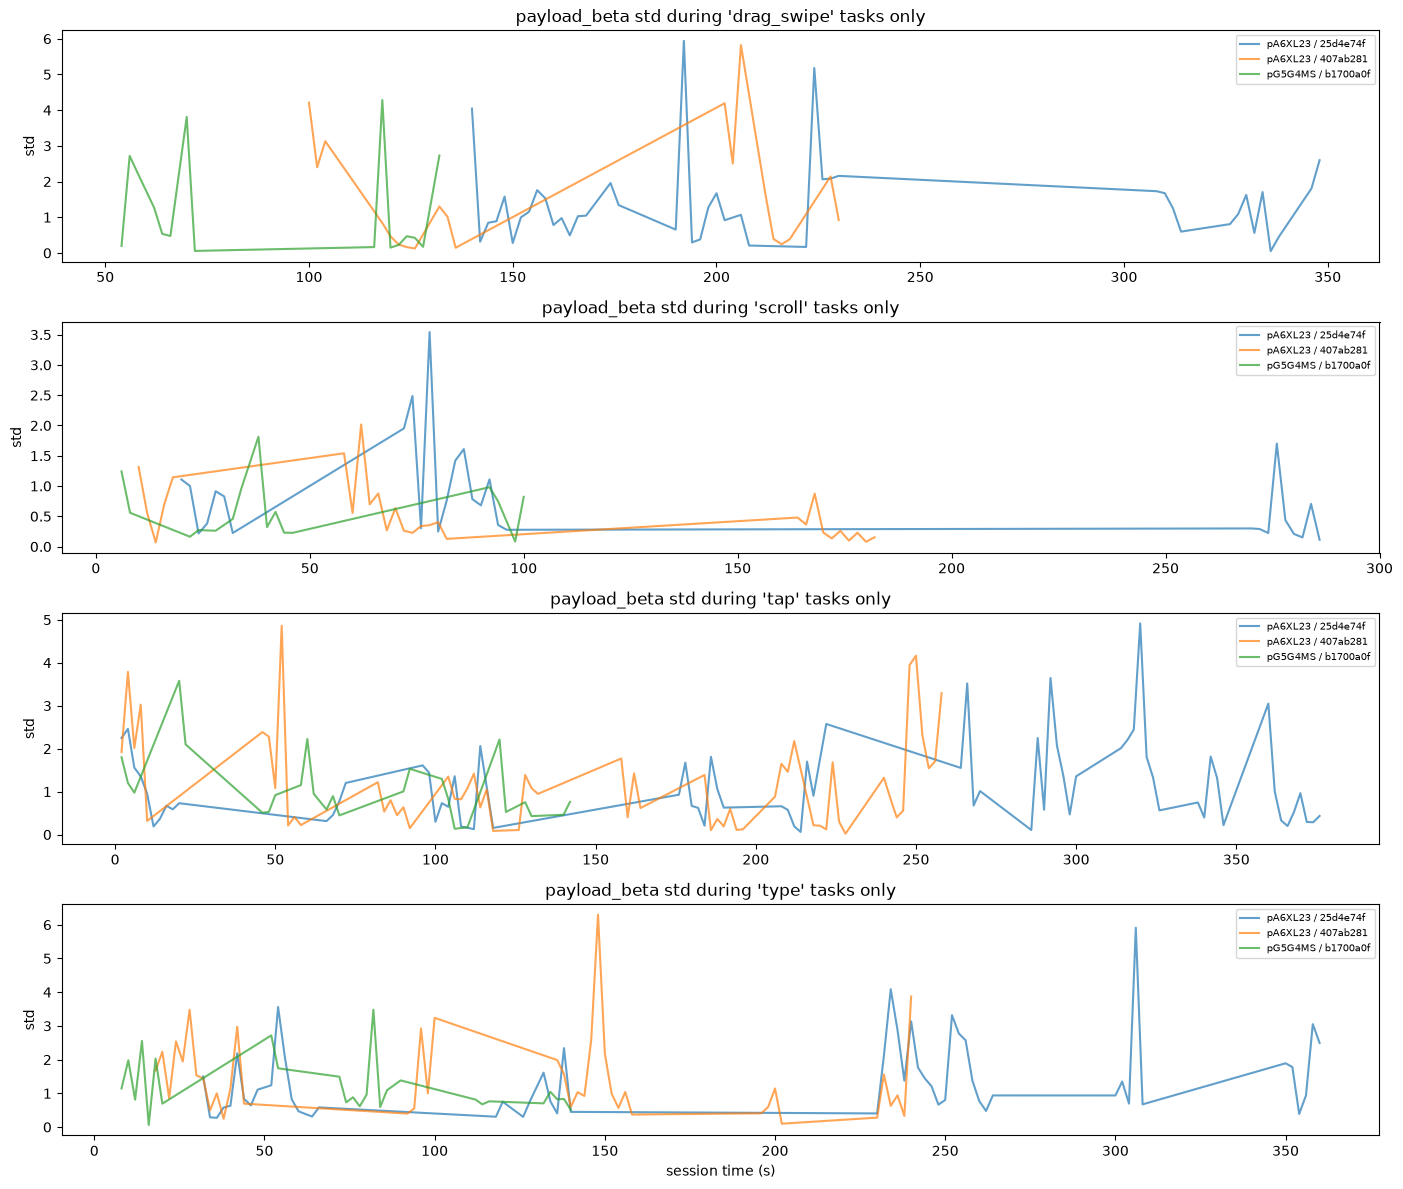

In [35]:
def rolling_variance_by_activity(tagged_df, payload_col, bin_seconds=2):
    activity_types = [a for a in tagged_df['activityType'].unique() if a != 'pre_task_or_other']
    fig, axes = plt.subplots(len(activity_types), 1, figsize=(14, 3 * len(activity_types)), squeeze=False)
    for i, activity in enumerate(sorted(activity_types)):
        ax = axes[i][0]
        sub = tagged_df[tagged_df['activityType'] == activity]
        for pid, p_sub in sub.groupby('participantId'):
            for sid, s_sub in p_sub.groupby('sessionId'):
                s_sub = s_sub.sort_values('tRelMs').copy()
                s_sub['time_bin'] = (s_sub['tRelMs'] // (bin_seconds * 1000)).astype(int)
                binned_std = s_sub.groupby('time_bin')[payload_col].std().dropna()
                if len(binned_std) < 2:
                    continue
                ax.plot(binned_std.index * bin_seconds, binned_std.values, alpha=0.7, label=f"{pid} / {sid[:8]}")
        ax.set_title(f"{payload_col} std during '{activity}' tasks only")
        ax.set_ylabel('std')
        ax.legend(fontsize=7)
    axes[-1][0].set_xlabel('session time (s)')
    plt.tight_layout()
    plt.show()

rolling_variance_by_activity(orient_tagged, 'payload_beta')

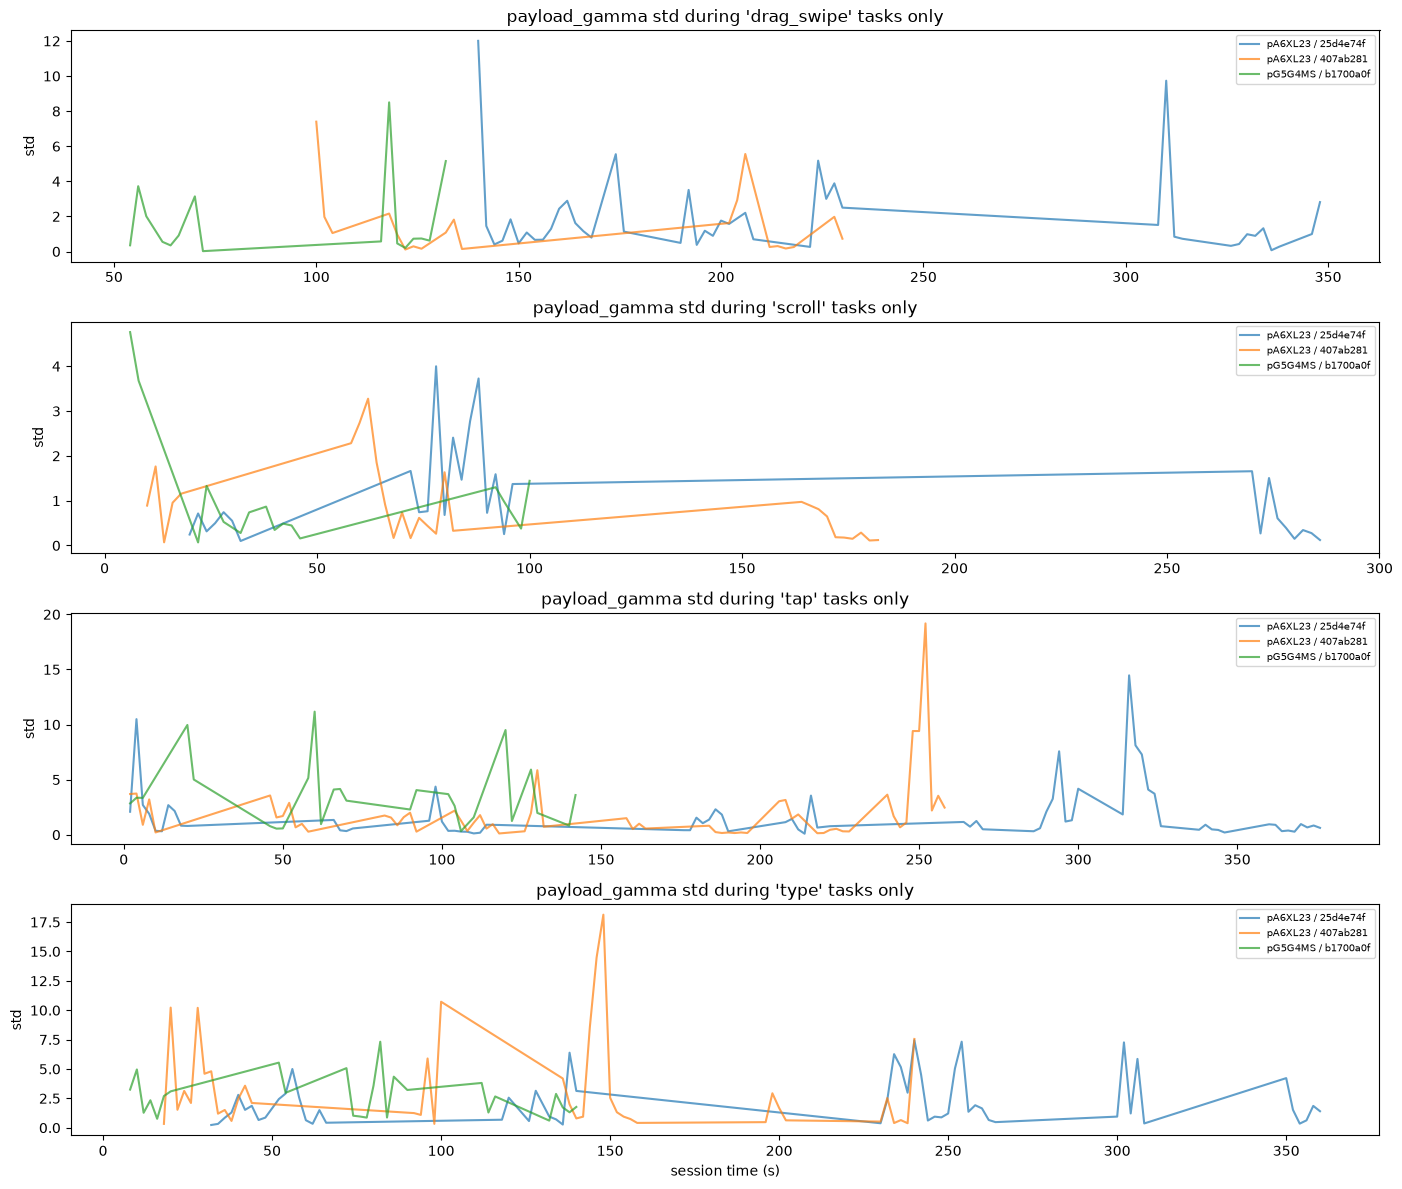

In [36]:
rolling_variance_by_activity(orient_tagged, 'payload_gamma')

**Read this as**: compare participants only within the same row (same activity type) —
that's the fair, like-for-like comparison. If separation still looks tangled even within a
single activity type, that's a more meaningful negative result than the whole-session version
was, since the task-driven confound has now been controlled for. If separation improves within
some activity types but not others, that tells you which task contexts are worth prioritizing
for this feature going forward.